In [1]:
import matplotlib.pyplot as plt
import pandas as pd
print(f'Pandas version {pd.__version__}')
import numpy as np
from scipy.stats import describe
from scipy.optimize import curve_fit
from moonstone.normalization.counts import geometric_mean

Pandas version 2.0.2


### Load the NORMALIZED count file.

In [12]:
# Read in the data file of reads and taxonomy
dr = pd.read_csv("FINAL_Bracken_GeoNorm_ncbiTax_Aug2024.csv")

# Melt the dataframe
melted = dr.melt(
    id_vars=['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'NCBI_taxonomy_ID'],
    value_vars=[col for col in dr.columns if col not in ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'NCBI_taxonomy_ID']],
    var_name='Sample',
    value_name='Abundance'
)
# Group by species and taxonomy ID along with Sample
grouped = melted.groupby(['species', 'NCBI_taxonomy_ID', 'Sample'], as_index=False)['Abundance'].sum()

# Pivot with a MultiIndex on rows: species + NCBI_taxonomy_ID
df = grouped.pivot(index=['species', 'NCBI_taxonomy_ID'], columns='Sample', values='Abundance').fillna(0)

taxa_metrics = pd.DataFrame({"percent present": 100 * (1 - (df == 0).astype(int).sum(axis=1) / df.shape[1]),
                           "mean reads": df.mean(axis=1),
                           "total reads": df.sum(axis=1)})

starting_items = df.shape[0]
display('Data has %i taxa' % starting_items)

'Data has 3717 taxa'

### Define formulas

In [13]:
# Define the bounded logistic model (taxa model)
def bounded_logistic(x, L, a, b):
    return L / (1 + a * x**b)

# Define generalized sigmoid function (reads model)
def generalized_sigmoid(x, L, k, x0, c):
    return L / (1 + np.exp(-k * (x - x0))) + c

# Define derivative of the generalized sigmoid function
def generalized_sigmoid_derivative(x, L, k, x0, c):
    exp_term = np.exp(-k * (x - x0))
    return (L * k * exp_term) / ((1 + exp_term) ** 2)

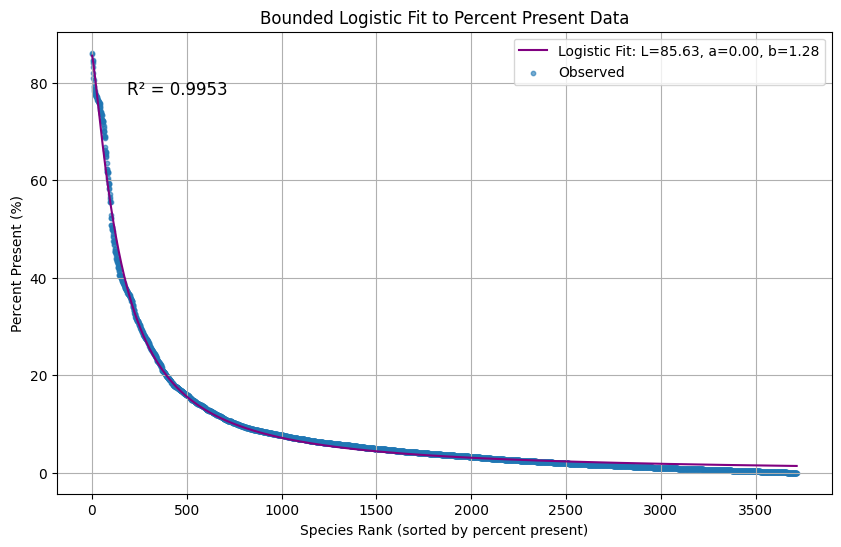

In [14]:
# Sort by percent present descending
sorted_metrics = taxa_metrics.sort_values(by='percent present', ascending=False).reset_index(drop=True)
x_data = np.arange(1, len(sorted_metrics) + 1)
y_data = sorted_metrics['percent present'].values

# Set dynamic bounds for L based on data max
max_present = y_data.max()
bounds_dynamic = ([max_present - 10, 0, -np.inf], [max_present + 10, np.inf, np.inf])

# Fit the model
popt, _ = curve_fit(bounded_logistic, x_data, y_data, bounds=bounds_dynamic, maxfev=5000)

# Predict fitted values
y_fit = bounded_logistic(x_data, *popt)

# Calculate R²
ss_res = np.sum((y_data - y_fit) ** 2)
ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, s=10, label='Observed', alpha=0.6)
plt.plot(x_data, y_fit, color='purple', label=f'Logistic Fit: L={popt[0]:.2f}, a={popt[1]:.2f}, b={popt[2]:.2f}')
plt.xlabel('Species Rank (sorted by percent present)')
plt.ylabel('Percent Present (%)')
plt.title('Bounded Logistic Fit to Percent Present Data')
plt.grid(True)
plt.legend()
plt.text(0.05 * len(x_data), 0.9 * max_present, f'R² = {r_squared:.4f}', fontsize=12, color='black')
plt.show()

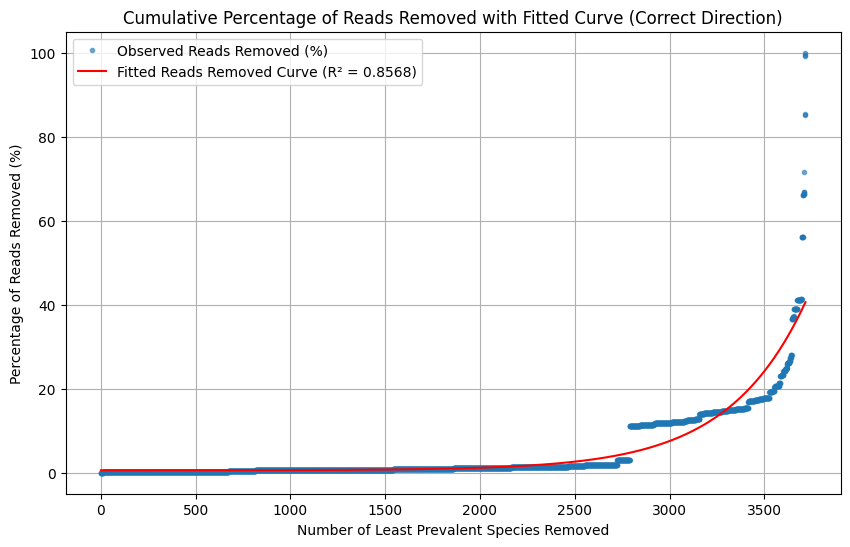

In [ ]:
# Sort by percent present ascending (least prevalent species removed first)
sorted_metrics = taxa_metrics.sort_values(by='percent present', ascending=True).reset_index(drop=True)
x_removal = np.arange(0, len(sorted_metrics) + 1)
y_total_reads = np.concatenate(([0], sorted_metrics['total reads'].cumsum().values))
y_total_reads_removed = y_total_reads  # Cumulative reads removed

# Express percentage of reads removed
reads_removed_percentage = (y_total_reads_removed / sorted_metrics['total reads'].sum()) * 100

# Fit sigmoid to percentage of reads removed
popt_sigmoid_final, _ = curve_fit(generalized_sigmoid, x_removal, reads_removed_percentage, p0=[100, -0.01, len(x_removal) / 2, 0], maxfev=5000)

# Predicted values from fitted curve
y_fit_removed_final = generalized_sigmoid(x_removal, *popt_sigmoid_final)

# R² calculation
ss_tot_final = np.sum((reads_removed_percentage - np.mean(reads_removed_percentage)) ** 2)
ss_res_final = np.sum((reads_removed_percentage - y_fit_removed_final) ** 2)
r_squared_final = 1 - (ss_res_final / ss_tot_final)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x_removal, reads_removed_percentage, 'o', markersize=3, label='Observed Reads Removed (%)', alpha=0.6)
plt.plot(x_removal, y_fit_removed_final, color='red', label=f'Fitted Reads Removed Curve (R² = {r_squared_final:.4f})')
plt.xlabel('Number of Least Prevalent Species Removed')
plt.ylabel('Percentage of Reads Removed (%)')
plt.title('Cumulative Percentage of Reads Removed with Fitted Curve')
plt.grid(True)
plt.legend()
plt.show()

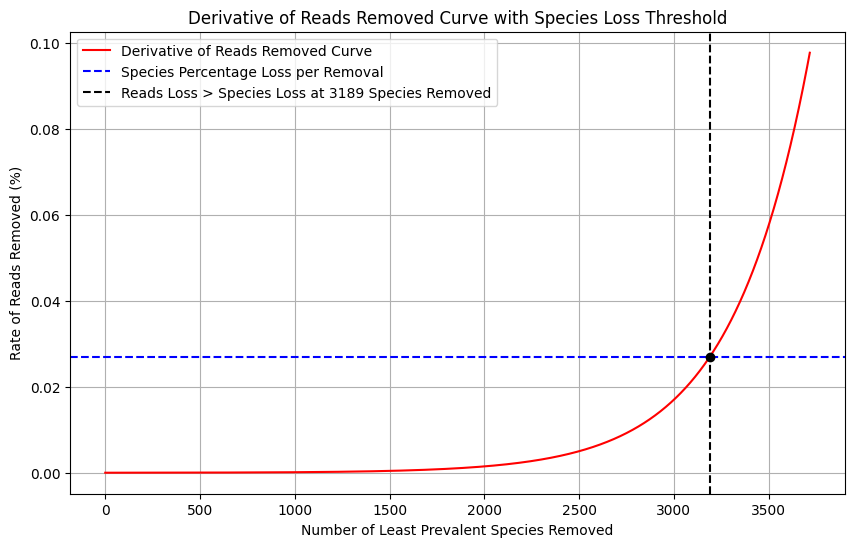

In [16]:
# Total number of species
total_species = len(sorted_metrics)

# Percentage loss per species removed
species_percentage_loss_per_removal = (1 / total_species) * 100



# Find first index where derivative of reads removed exceeds species percentage loss
# Calculate derivative of the fitted reads removed curve
reads_derivative_final = generalized_sigmoid_derivative(x_removal, *popt_sigmoid_final)
exceed_indices = np.where(reads_derivative_final > species_percentage_loss_per_removal)[0]

# Determine first such occurrence
if exceed_indices.size > 0:
    first_exceed_idx = exceed_indices[0]
    species_removed_count_exceed = x_removal[first_exceed_idx]
    derivative_value_exceed = reads_derivative_final[first_exceed_idx]
else:
    species_removed_count_exceed = None
    derivative_value_exceed = None

# Plot derivative with threshold marked
plt.figure(figsize=(10, 6))
plt.plot(x_removal, reads_derivative_final, color='red', label='Derivative of Reads Removed Curve')
plt.axhline(species_percentage_loss_per_removal, color='blue', linestyle='--', label='Species Percentage Loss per Removal')
if species_removed_count_exceed is not None:
    plt.axvline(species_removed_count_exceed, color='black', linestyle='--', label=f'Reads Loss > Species Loss at {species_removed_count_exceed} Species Removed')
    plt.scatter([species_removed_count_exceed], [derivative_value_exceed], color='black', zorder=5)
plt.xlabel('Number of Least Prevalent Species Removed')
plt.ylabel('Rate of Reads Removed (%)')
plt.title('Derivative of Reads Removed Curve with Species Loss Threshold')
plt.grid(True)
plt.legend()
plt.show()

In [17]:
# Total number of species
total_species = len(sorted_metrics)

# Calculate percentage of species removed
species_pct_removed = (species_removed_count_exceed / total_species) * 100

# Calculate percentage of reads removed at that point using observed values
reads_pct_removed = reads_removed_percentage[species_removed_count_exceed]

# Determine the minimum number of reads among the retained species
retained_species = sorted_metrics.iloc[species_removed_count_exceed:]
min_reads_retained = retained_species['total reads'].min()

species_pct_removed, reads_pct_removed, min_reads_retained

(85.79499596448748, 14.245188923393359, 2490.2279247487127)